array([[159, 158, 158, ..., 135, 135, 135],
       [187, 187, 186, ..., 156, 157, 158],
       [187, 187, 188, ..., 156, 157, 156],
       ...,
       [ 51,  85,  81, ..., 141, 142, 141],
       [ 92,  86,  81, ..., 143, 142, 141],
       [114,  74,  73, ..., 142, 141, 139]], dtype=uint8)
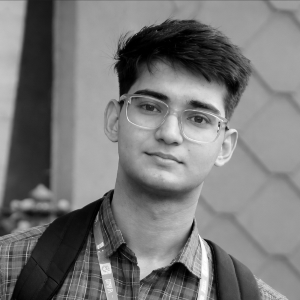

In [15]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow #cv2.imshow() doesn't work on colab
img = cv2.imread("/content/1775662781597.png") #read
img = cv2.resize(img,(300,300)) #making it smaller
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #gray_scale
gray

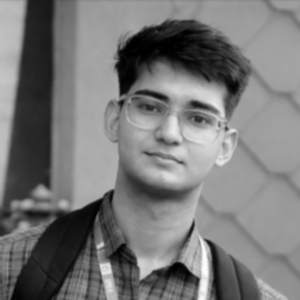

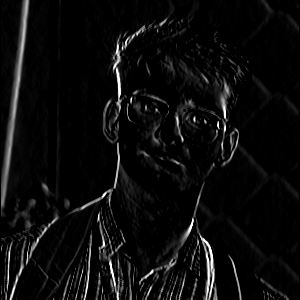

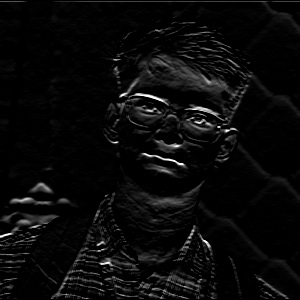

In [25]:
#Defining all kinds of kernel manually
blur_kernel = np.array([
    [1,2,1],
    [2,4,2],
    [1,2,1]
])/16
vert_edge_kernel = np.array([
    [1,0,-1],
    [1,0,-1],
    [1,0,-1]
])
horz_edge_kernel = np.array([
    [-1,-1,-1],
    [0,0,0],
    [1,1,1]
])

#cv2.filter2D() just does the convolution on the image with the kernel specified
blur = cv2.filter2D(gray,-1,blur_kernel)
vert_edge = cv2.filter2D(gray,-1,vert_edge_kernel)
horz_edge = cv2.filter2D(gray,-1,horz_edge_kernel)

#output
cv2_imshow(blur)
cv2_imshow(vert_edge)
cv2_imshow(horz_edge)

In [26]:
#Defining the convolution function from scratch

def convolution(img,kernel):

  output = np.zeros(img.shape) #same sized matrix as image
  for i in range(1,img.shape[0]-1): #since kernel size is 3x3 we have to leave on pixel on each side
    for j in range(1,img.shape[1]-1): #since kernel size is 3x3 we have to leave on pixel on each side
      region = img[i-1:i+2,j-1:j+2] #region on which the kernel will be applied
      val = np.sum(region*kernel) #product
      output[i,j] = val #storing the values

  return output

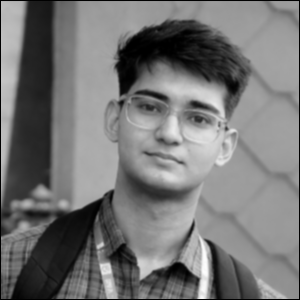

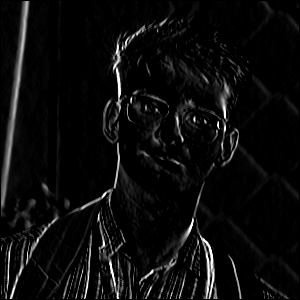

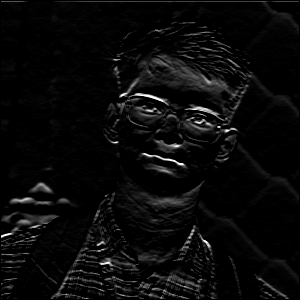

In [28]:
#Convolution function works
blur = convolution(gray,blur_kernel)
vert_edge = convolution(gray,vert_edge_kernel)
horz_edge = convolution(gray,horz_edge_kernel)

cv2_imshow(blur)
cv2_imshow(vert_edge)
cv2_imshow(horz_edge)

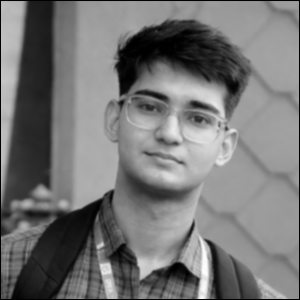

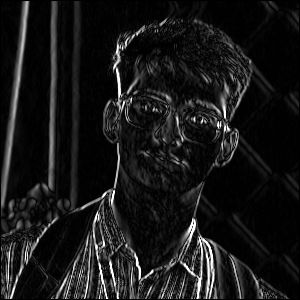

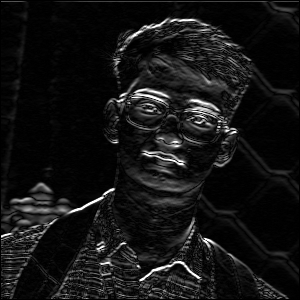

In [29]:
#To adjust for the negative values obtained during convolution

blur = cv2.convertScaleAbs(blur)
vert_edge = cv2.convertScaleAbs(vert_edge)
horz_edge = cv2.convertScaleAbs(horz_edge)

cv2_imshow(blur)
cv2_imshow(vert_edge)
cv2_imshow(horz_edge)

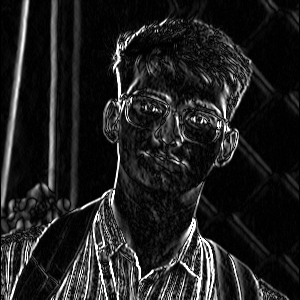

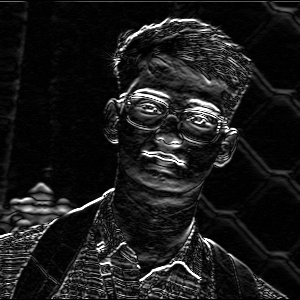

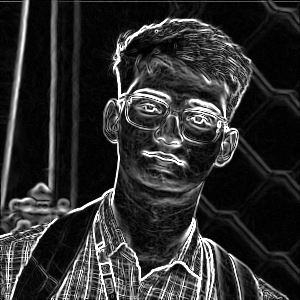

In [41]:
#Trying out popular edge detection ops

gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
result = np.sqrt(gx**2 + gy**2)

abs_gx = cv2.convertScaleAbs(gx)
abs_gy = cv2.convertScaleAbs(gy)
abs_result = cv2.convertScaleAbs(result) #Combining the results of vert and horz edges detected

cv2_imshow(abs_gx)
cv2_imshow(abs_gy)
cv2_imshow(abs_result)


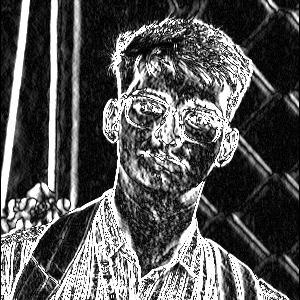

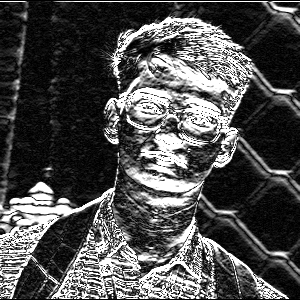

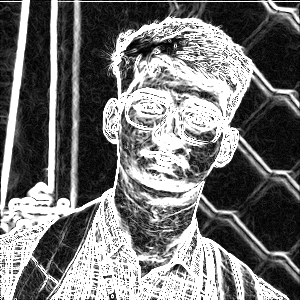

In [42]:
scharr_x = cv2.Scharr(gray, cv2.CV_64F, 1, 0)
scharr_y = cv2.Scharr(gray, cv2.CV_64F, 0, 1)
scharr_result = np.sqrt(scharr_x**2 + scharr_y**2)

abs_scharr_x = cv2.convertScaleAbs(scharr_x)
abs_scharr_y = cv2.convertScaleAbs(scharr_y)
abs_scharr_result = cv2.convertScaleAbs(scharr_result)

cv2_imshow(abs_scharr_x)
cv2_imshow(abs_scharr_y)
cv2_imshow(abs_scharr_result)

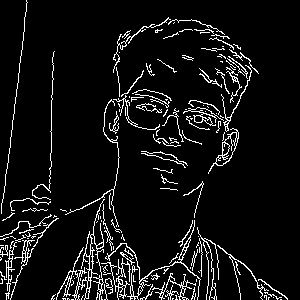

In [43]:
# The thresholds (100 and 200) determine which gradients are considered true edges
canny_edges = cv2.Canny(gray, threshold1=100, threshold2=200)

cv2_imshow(canny_edges)